In [1]:
import subprocess, sys

def run(cmd, label=''):
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(f'  {label or cmd[-1]}: {"OK" if r.returncode==0 else "FAILED"}')
    if r.returncode != 0:
        print(f'    {r.stderr[-150:]}')
    return r.returncode == 0

print('Installing packages...')
run([sys.executable, '-m', 'pip', 'install', '-q', 'segmentation-models-pytorch'], 'smp')
run([sys.executable, '-m', 'pip', 'install', '-q', 'timm'], 'timm')
run([sys.executable, '-m', 'pip', 'install', '-q', 'zarr', 'zstandard'], 'zarr+zstd')

import torch
import segmentation_models_pytorch as smp
import timm

print(f'\ntorch: {torch.__version__}')
print(f'smp:   {smp.__version__}')
print(f'timm:  {timm.__version__}')
print(f'GPU:   {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Installing packages...
  smp: OK
  timm: OK
  zarr+zstd: OK

torch: 2.10.0+cu128
smp:   0.5.0
timm:  1.0.26
GPU:   Tesla T4


In [2]:
import os, json, glob, time, gc
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import cv2
from skimage.feature import peak_local_max

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f'Device: {DEVICE} | GPUs: {N_GPUS}')

# --- Paths ---
CAND = [
    '/kaggle/input/competitions/biohub-cell-tracking-during-development',
    '/kaggle/input/biohub-cell-tracking-during-development',
]
ROOT = next((p for p in CAND if Path(p,'train').exists()), None)
if ROOT is None:
    raise FileNotFoundError(f'Data not found. Checked: {CAND}')
TRAIN_DIR = Path(ROOT) / 'train'
TEST_DIR  = Path(ROOT) / 'test'
OUT_DIR   = Path('/kaggle/working')
CKPT_BEST  = OUT_DIR / 'smp_unet_resnet34_best.pt'
CKPT_FINAL = OUT_DIR / 'smp_unet_resnet34_final.pt'
META_PATH  = OUT_DIR / 'smp_meta.json'

# --- Architecture ---
ENCODER      = 'resnet34'   # ImageNet pretrained backbone
                              # alternatives: 'efficientnet-b0', 'resnet18', 'mobilenet_v2'
                              # resnet34 is the best balance of speed and capacity
ENCODER_WEIGHTS = 'imagenet' # pretrained weights source
DECODER      = 'Unet'        # decoder architecture: Unet, UnetPlusPlus, FPN, DeepLabV3Plus
IN_CHANNELS  = 3             # 3 = 2.5D context [z-1, z, z+1]
                              # timm handles 3-channel grayscale input via weight averaging

# --- Spatial ---
POOL = 2                     # XY pooling factor before feeding to network
                              # 2 = better resolution than POOL=4, manageable memory
IMG_SIZE = 128               # H and W fed to network after pooling
                              # at POOL=2: 128px = 256 original voxels (full FOV)

# --- Training ---
EPOCHS       = 20
BATCH        = 8 * max(N_GPUS, 1)
LR           = 3e-4
SEED         = 42

# --- Heatmap target ---
GAUSS_SIGMA  = 4.0           # Gaussian blob radius in pooled pixels
                              # 4.0 pooled px at POOL=2 = 8 original voxels = ~3.25 um

# --- PU loss weights ---
W_POS  = 20.0                # annotated nucleus centres
W_BG   = 1.0                 # clearly dark background
W_IGN  = 0.01                # bright unannotated (likely real cells)

# --- Detection ---
NUCLEUS_DIAM_UM   = 8.0
VOXEL_XY_POOLED   = 0.40625 * POOL
MIN_PEAK_DISTANCE = max(4, int(NUCLEUS_DIAM_UM / VOXEL_XY_POOLED))  # ~4px at POOL=2

# --- Hard negatives ---
Z_MARGIN          = 5        # slices around GT node = nucleus region
NEG_SLICES_PER_T  = 4        # tissue-edge hard negatives per timepoint

# --- Val ---
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
TEST4      = ['6bba_05b6850b', '6bba_05db0fb1', '44b6_0113de3b', '44b6_0b24845f']

RNG = np.random.default_rng(SEED)
torch.manual_seed(SEED)

print(f'Encoder: {ENCODER} ({ENCODER_WEIGHTS}) | Decoder: {DECODER}')
print(f'IN_CHANNELS={IN_CHANNELS} | POOL={POOL} | IMG_SIZE={IMG_SIZE}')
print(f'GAUSS_SIGMA={GAUSS_SIGMA} | MIN_PEAK_DISTANCE={MIN_PEAK_DISTANCE}px')
print(f'BATCH={BATCH} | LR={LR} | EPOCHS={EPOCHS}')

Device: cuda | GPUs: 2
Encoder: resnet34 (imagenet) | Decoder: Unet
IN_CHANNELS=3 | POOL=2 | IMG_SIZE=128
GAUSS_SIGMA=4.0 | MIN_PEAK_DISTANCE=9px
BATCH=16 | LR=0.0003 | EPOCHS=20


In [3]:
# segmentation_models_pytorch.Unet wraps a pretrained ImageNet encoder
# (resnet34) with a lightweight decoder trained from scratch.
#
# WHY THIS IS BETTER THAN OUR CUSTOM UNet:
# - resnet34 encoder has 21M params trained on 1.2M ImageNet images
# - It has already learned to detect edges, textures, blob shapes
# - These features transfer well to fluorescence microscopy
#   (nuclei are blob-shaped objects, which ImageNet models detect well)
# - in_channels=3 with pretrained=imagenet means timm averages the 3
#   RGB channel weights into our 3 grayscale context channels -- valid
#   transfer for 2.5D context stacking
# - The decoder is a simple upsampling network trained from scratch
#   on our specific heatmap regression task

model = smp.Unet(
    encoder_name    = ENCODER,
    encoder_weights = ENCODER_WEIGHTS,   # ImageNet pretrained
    in_channels     = IN_CHANNELS,       # 3 for 2.5D context
    classes         = 1,                 # single heatmap output channel
    activation      = None,              # raw logits; sigmoid applied in loss
    decoder_channels = (256, 128, 64, 32, 16),
    decoder_use_batchnorm = True,
)

model = model.to(DEVICE)
if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel on {N_GPUS} GPUs')

n_enc = sum(p.numel() for p in model.encoder.parameters()
            if not isinstance(model, nn.DataParallel)) if not isinstance(model, nn.DataParallel) \
        else sum(p.numel() for p in model.module.encoder.parameters())
n_total = sum(p.numel() for p in model.parameters())
print(f'Total params: {n_total:,}')

# quick forward pass to verify shapes
with torch.no_grad():
    _x = torch.zeros(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _o = model(_x)
    assert _o.shape == (2, 1, IMG_SIZE, IMG_SIZE), f'Wrong shape: {_o.shape}'
    print(f'Forward OK: {tuple(_x.shape)} -> {tuple(_o.shape)}')
    del _x, _o

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

DataParallel on 2 GPUs
Total params: 24,436,369
Forward OK: (2, 3, 128, 128) -> (2, 1, 128, 128)


In [4]:
import zstandard

_ZC = {}

def read_meta(zp):
    with open(Path(zp)/'0'/'zarr.json') as f:
        m = json.load(f)
    return dict(shape=tuple(m['shape']), dtype=np.dtype(m['data_type']))

def load_vol(zp, t, meta=None):
    try:
        import zarr
        k = str(zp)
        if k not in _ZC:
            _ZC[k] = zarr.open(k, mode='r')['0']
        return np.asarray(_ZC[k][t])
    except Exception:
        import blosc2
        if meta is None:
            meta = read_meta(zp)
        buf = blosc2.decompress(
            open(Path(zp)/'0'/'c'/str(t)/'0'/'0'/'0','rb').read()
        )
        return np.frombuffer(buf, dtype=meta['dtype']).reshape(meta['shape'][1:])

def pool_xy(vol, f=POOL):
    Z, Y, X = vol.shape
    Y2, X2 = (Y//f)*f, (X//f)*f
    v = vol[:, :Y2, :X2].astype(np.float32, copy=False)
    return v.reshape(Z, Y2//f, f, X2//f, f).mean(axis=(2,4))

def normalize_clahe(slc, clip=3.0, grid=8):
    lo = float(np.percentile(slc, 2.0))
    hi = float(np.percentile(slc, 99.0))
    if hi <= lo:
        return np.zeros_like(slc, dtype=np.float32)
    scaled = np.clip((slc-lo)/(hi-lo)*255, 0, 255).astype(np.uint8)
    return cv2.createCLAHE(clipLimit=clip,
                            tileGridSize=(grid,grid)).apply(scaled).astype(np.float32)/255.0

def load_context_stack(pvol, z, n_ch=IN_CHANNELS):
    """Returns (n_ch, H, W): CLAHE-normalized slices centred on z."""
    Z = pvol.shape[0]
    half = n_ch // 2
    slices = []
    for dz in range(-half, half+1):
        z_idx = int(np.clip(z+dz, 0, Z-1))
        slices.append(normalize_clahe(pvol[z_idx]))
    return np.stack(slices, axis=0)  # (n_ch, H, W)

def read_geff_nodes(geff_path):
    def _dec(path):
        path = Path(path)
        m  = json.load(open(path/'zarr.json'))
        dt = np.dtype(m['data_type'])
        n  = int(m['shape'][0])
        buf = zstandard.ZstdDecompressor().decompress(
            open(path/'c'/'0','rb').read()
        )
        return np.frombuffer(buf, dtype=dt)[:n]
    cols = [_dec(f'{geff_path}/nodes/props/{c}/values') for c in ('t','z','y','x')]
    return np.stack(cols, axis=1).astype(np.float64)

print('Cell 4 complete.')

Cell 4 complete.


In [5]:
import collections, random

def all_movies():
    zarr_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.zarr')}
    geff_names = {Path(p).name[:-5] for p in glob.glob(f'{TRAIN_DIR}/*.geff')}
    return sorted(zarr_names & geff_names)

def make_splits(n_val_per_embryo=8, seed=SEED):
    pool = [m for m in all_movies() if m not in TEST4]
    by_embryo = collections.defaultdict(list)
    for m in pool:
        by_embryo[m.split('_')[0]].append(m)
    rng = random.Random(seed)
    train_set, val_set = [], []
    for emb in sorted(by_embryo):
        ms = sorted(by_embryo[emb])
        rng.shuffle(ms)
        val_set.extend(ms[:n_val_per_embryo])
        train_set.extend(ms[n_val_per_embryo:])
    return train_set, val_set

train_movies, val_movies = make_splits()
print(f'Train: {len(train_movies)} | Val: {len(val_movies)} | Held out: {len(TEST4)}')

# Check embryo distribution
from collections import Counter
train_embryos = Counter(m.split('_')[0] for m in train_movies)
val_embryos   = Counter(m.split('_')[0] for m in val_movies)
print(f'Train embryos: {dict(train_embryos)}')
print(f'Val embryos:   {dict(val_embryos)}')

Train: 179 | Val: 16 | Held out: 4
Train embryos: {'44b6': 61, '6bba': 118}
Val embryos:   {'44b6': 8, '6bba': 8}


In [6]:
def load_movie_slices(ds, fpm=12, spf=8):
    zp    = str(TRAIN_DIR / f'{ds}.zarr')
    gp    = str(TRAIN_DIR / f'{ds}.geff')
    meta  = read_meta(zp)
    nodes = read_geff_nodes(gp)

    node_t = nodes[:, 0].round().astype(int)
    node_z = nodes[:, 1].round().astype(int)
    node_y = nodes[:, 2]
    node_x = nodes[:, 3]

    ann_t = sorted(set(node_t.tolist()) & set(range(meta['shape'][0])))
    if not ann_t:
        return []

    t_idx    = np.linspace(0, len(ann_t)-1, min(fpm, len(ann_t))).round().astype(int)
    chosen_t = sorted(set(ann_t[i] for i in t_idx))

    out = []
    for t in chosen_t:
        vol  = load_vol(zp, t, meta)
        pvol = pool_xy(vol)
        Z    = pvol.shape[0]

        mask_t = node_t == t
        ann_z  = node_z[mask_t]
        ann_y  = node_y[mask_t]
        ann_x  = node_x[mask_t]

        # positive slices: Z positions that have GT annotations
        ann_z_unique = sorted(set(ann_z.tolist()))
        z_idx    = np.linspace(0, len(ann_z_unique)-1,
                               min(spf, len(ann_z_unique))).round().astype(int)
        chosen_z = sorted(set(ann_z_unique[i] for i in z_idx))

        for z in chosen_z:
            ctx   = load_context_stack(pvol, z)   # (3, H, W)
            in_s  = ann_z == z
            pts_y = ann_y[in_s] / POOL
            pts_x = ann_x[in_s] / POOL
            pts   = np.stack([pts_y, pts_x], axis=1).astype(np.float32)
            out.append((ctx, pts, 'positive'))

        # hard negative slices: far from any GT node in Z
        safe_z = set()
        for gz in ann_z_unique:
            for dz in range(-Z_MARGIN, Z_MARGIN+1):
                if 0 <= gz+dz < Z:
                    safe_z.add(gz+dz)

        cand_neg = [z for z in range(2, Z-2) if z not in safe_z]
        if cand_neg:
            n_neg    = min(NEG_SLICES_PER_T, len(cand_neg))
            neg_idx  = np.linspace(0, len(cand_neg)-1, n_neg).round().astype(int)
            for z in [cand_neg[i] for i in neg_idx]:
                ctx = load_context_stack(pvol, z)
                out.append((ctx, np.zeros((0, 2), dtype=np.float32), 'negative'))

    return out

t0 = time.time()
train_cache, val_cache = [], []
neg_count = 0

for i, ds in enumerate(train_movies):
    slices = load_movie_slices(ds, fpm=12, spf=8)
    train_cache += [(s, p) for s, p, k in slices]
    neg_count   += sum(1 for _, _, k in slices if k == 'negative')
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(train_movies)} train movies, {len(train_cache)} slices ({time.time()-t0:.0f}s)')

for ds in val_movies:
    slices = load_movie_slices(ds, fpm=4, spf=4)
    val_cache += [(s, p) for s, p, k in slices]

print(f'Train: {len(train_cache)} slices ({neg_count} hard negatives, '
      f'{100*neg_count/max(len(train_cache),1):.1f}%)')
print(f'Val:   {len(val_cache)} slices | {time.time()-t0:.0f}s total')

  20/179 train movies, 1611 slices (45s)
  40/179 train movies, 3101 slices (87s)
  60/179 train movies, 4833 slices (131s)
  80/179 train movies, 7225 slices (174s)
  100/179 train movies, 9694 slices (217s)
  120/179 train movies, 12158 slices (262s)
  140/179 train movies, 14606 slices (306s)
  160/179 train movies, 17000 slices (347s)
Train: 19284 slices (8150 hard negatives, 42.3%)
Val:   444 slices | 399s total


In [7]:
def stamp_heatmap_2d(shape, pts, sigma=GAUSS_SIGMA):
    hm = np.zeros(shape, np.float32)
    if len(pts) == 0:
        return hm
    r  = int(np.ceil(3 * sigma))
    yy, xx = np.mgrid[-r:r+1, -r:r+1]
    g  = np.exp(-(yy**2 + xx**2) / (2 * sigma**2)).astype(np.float32)
    H, W = shape
    for cy, cx in pts:
        cy, cx = int(round(cy)), int(round(cx))
        y0, y1 = max(0, cy-r), min(H, cy+r+1)
        x0, x1 = max(0, cx-r), min(W, cx+r+1)
        gy, gx = y0-(cy-r), x0-(cx-r)
        sub = g[gy:gy+(y1-y0), gx:gx+(x1-x0)]
        np.maximum(hm[y0:y1, x0:x1], sub, out=hm[y0:y1, x0:x1])
    return hm

def build_sample(ctx, pts, augment=True):
    """ctx: (3, H, W) | pts: (N, 2) GT in pooled coords"""
    x   = ctx.copy()
    mid = x[IN_CHANNELS // 2]
    tgt = stamp_heatmap_2d(mid.shape, pts)

    if augment:
        if RNG.random() < 0.5:
            x = np.flip(x, axis=2).copy(); tgt = np.fliplr(tgt).copy()
        if RNG.random() < 0.5:
            x = np.flip(x, axis=1).copy(); tgt = np.flipud(tgt).copy()
        k = RNG.integers(0, 4)
        if k > 0:
            x   = np.rot90(x, k, axes=(1,2)).copy()
            tgt = np.rot90(tgt, k).copy()
        # brightness/contrast augmentation
        if RNG.random() < 0.5:
            x = np.clip(x * RNG.uniform(0.7, 1.3), 0, 1).astype(np.float32)
        if RNG.random() < 0.3:
            x = np.clip(x + RNG.normal(0, 0.04, x.shape).astype(np.float32), 0, 1)

    # PU weighting
    w = np.full(tgt.shape, W_IGN, np.float32)
    w[mid < np.quantile(mid, 0.40)] = W_BG
    if len(pts) > 0:
        w[tgt > 0.05] = W_POS
    else:
        w[:] = W_BG  # hard negative: penalise all firing

    return x, tgt[None], w[None]

bce_loss = nn.BCEWithLogitsLoss(reduction='none')
print('Cell 7 complete.')

Cell 7 complete.


In [8]:
def compute_val_metrics(model, val_cache, tol=2.5):
    model.eval()
    hits        = {t: 0   for t in THRESHOLDS}
    totals      = {t: 0   for t in THRESHOLDS}
    peak_counts = {t: []  for t in THRESHOLDS}
    val_loss_sum = 0.0; val_loss_n = 0

    with torch.no_grad():
        for ctx, pts in val_cache:
            mid    = ctx[IN_CHANNELS // 2]
            xt     = torch.from_numpy(ctx[None]).to(DEVICE, non_blocking=True)
            logits = model(xt)
            hm     = torch.sigmoid(logits)[0, 0].float().cpu().numpy()

            tgt_np = stamp_heatmap_2d(mid.shape, pts)
            w_np   = np.full(tgt_np.shape, W_IGN, np.float32)
            w_np[mid < np.quantile(mid, 0.40)] = W_BG
            if len(pts) > 0:
                w_np[tgt_np > 0.05] = W_POS
            else:
                w_np[:] = W_BG

            yb = torch.from_numpy(tgt_np[None, None]).to(DEVICE, non_blocking=True)
            wb = torch.from_numpy(w_np[None, None]).to(DEVICE, non_blocking=True)
            vloss = (bce_loss(logits, yb) * wb).sum() / wb.sum()
            val_loss_sum += vloss.detach().item(); val_loss_n += 1

            for thresh in THRESHOLDS:
                pk = peak_local_max(hm, min_distance=MIN_PEAK_DISTANCE,
                                    threshold_abs=thresh,
                                    exclude_border=False).astype(np.float32)
                peak_counts[thresh].append(len(pk))
                for p in pts:
                    totals[thresh] += 1
                    if len(pk) and np.min(np.linalg.norm(pk - p, axis=1)) <= tol:
                        hits[thresh] += 1

    recalls     = {t: hits[t]/max(totals[t], 1) for t in THRESHOLDS}
    avg_peaks   = {t: np.mean(peak_counts[t])    for t in THRESHOLDS}
    best_thresh = max(recalls, key=recalls.get)
    model.train()
    return recalls[best_thresh], val_loss_sum/max(val_loss_n,1), best_thresh, recalls, avg_peaks

print('Cell 8 complete.')

Cell 8 complete.


In [9]:
# Differential LR: encoder (pretrained) gets 10x lower LR than decoder (random init)
# This is the standard fine-tuning strategy for pretrained backbones --
# too high an LR on the encoder destroys the ImageNet features
core = model.module if isinstance(model, nn.DataParallel) else model

optimizer = torch.optim.AdamW([
    {'params': core.encoder.parameters(), 'lr': LR / 10},  # pretrained -- low LR
    {'params': core.decoder.parameters(), 'lr': LR},        # random init -- full LR
    {'params': core.segmentation_head.parameters(), 'lr': LR},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR/100
)

best_recall       = 0.0
best_thresh_final = THRESHOLDS[0]
best_state        = None
indices           = np.arange(len(train_cache))
history           = {'epoch':[], 'train_loss':[], 'val_loss':[],
                     'val_recall':[], 'best_thresh':[]}

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()
    model.train()
    RNG.shuffle(indices)
    train_loss_sum = 0.0; train_loss_n = 0

    for b_start in range(0, len(indices), BATCH):
        batch_idx = indices[b_start:b_start + BATCH]
        xs, ys, ws = [], [], []
        for i in batch_idx:
            ctx, pts = train_cache[i]
            x, y, w  = build_sample(ctx, pts, augment=True)
            xs.append(x); ys.append(y); ws.append(w)

        xb = torch.from_numpy(np.stack(xs)).to(DEVICE, non_blocking=True)
        yb = torch.from_numpy(np.stack(ys)).to(DEVICE, non_blocking=True)
        wb = torch.from_numpy(np.stack(ws)).to(DEVICE, non_blocking=True)

        if epoch == 1 and b_start == 0:
            print(f'Batch shapes: x={xb.shape}, y={yb.shape}, w={wb.shape}')
            # Expected: x=(BATCH, 3, H, W)  y=(BATCH, 1, H, W)  w=(BATCH, 1, H, W)

        optimizer.zero_grad()
        logits = model(xb)
        loss   = (bce_loss(logits, yb) * wb).sum() / wb.sum()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss_sum += loss.detach().item(); train_loss_n += 1

    scheduler.step()
    train_loss = train_loss_sum / max(train_loss_n, 1)
    val_recall, val_loss, best_thresh, recalls, avg_peaks = \
        compute_val_metrics(model, val_cache)

    is_best  = val_recall > best_recall
    elapsed  = (time.time() - t_start) / 60
    enc_lr   = optimizer.param_groups[0]['lr']
    dec_lr   = optimizer.param_groups[1]['lr']

    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'train={train_loss:.4f} | val={val_loss:.4f} | '
          f'recall={val_recall:.3f}@{best_thresh:.2f} | '
          f'lr={enc_lr:.2e}/{dec_lr:.2e} | '
          f'{elapsed:.1f}min{" <- BEST" if is_best else ""}')
    sweep = '  '.join(
        f'{t:.2f}:r={recalls[t]:.3f}/pk={avg_peaks[t]:.0f}' for t in THRESHOLDS
    )
    print(f'  {sweep}')

    core = model.module if isinstance(model, nn.DataParallel) else model

    if is_best:
        best_recall       = val_recall
        best_thresh_final = best_thresh
        best_state        = {k: v.cpu().clone() for k, v in core.state_dict().items()}
        torch.save(best_state, CKPT_BEST)
        print(f'  -> Saved: {CKPT_BEST}')

    torch.save(
        {k: v.cpu().clone() for k, v in core.state_dict().items()},
        CKPT_FINAL
    )

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_recall'].append(val_recall)
    history['best_thresh'].append(best_thresh)
    gc.collect()

# save metadata
meta_dict = {
    'encoder':           ENCODER,
    'encoder_weights':   ENCODER_WEIGHTS,
    'decoder':           DECODER,
    'in_channels':       IN_CHANNELS,
    'pool':              POOL,
    'img_size':          IMG_SIZE,
    'gauss_sigma':       GAUSS_SIGMA,
    'best_thresh':       best_thresh_final,
    'best_val_recall':   best_recall,
    'min_peak_distance': MIN_PEAK_DISTANCE,
    'nucleus_diam_um':   NUCLEUS_DIAM_UM,
    'w_pos':             W_POS,
    'w_bg':              W_BG,
    'w_ign':             W_IGN,
    'epochs_trained':    EPOCHS,
    'nms_radius_xy':     3.0,
    'nms_radius_z':      3,
    'detect_thresh':     best_thresh_final,
    'model_type':        'smp',   # flag for inference notebook
}
with open(META_PATH, 'w') as f:
    json.dump(meta_dict, f, indent=2)

print(f'\nDone. Best recall={best_recall:.3f} @ thresh={best_thresh_final}')
print(f'Checkpoint: {CKPT_BEST}')
print(f'Metadata:   {META_PATH}')

Batch shapes: x=torch.Size([16, 3, 128, 128]), y=torch.Size([16, 1, 128, 128]), w=torch.Size([16, 1, 128, 128])
Epoch  1/20 | train=0.2223 | val=0.1759 | recall=0.599@0.05 | lr=2.98e-05/2.98e-04 | 2.5min <- BEST
  0.05:r=0.599/pk=17  0.10:r=0.599/pk=15  0.15:r=0.586/pk=13  0.20:r=0.577/pk=12  0.25:r=0.559/pk=10  0.30:r=0.541/pk=9  0.35:r=0.500/pk=8  0.40:r=0.437/pk=6  0.45:r=0.383/pk=5  0.50:r=0.320/pk=3
  -> Saved: /kaggle/working/smp_unet_resnet34_best.pt
Epoch  2/20 | train=0.1874 | val=0.1756 | recall=0.590@0.05 | lr=2.93e-05/2.93e-04 | 2.5min
  0.05:r=0.590/pk=15  0.10:r=0.586/pk=14  0.15:r=0.577/pk=13  0.20:r=0.568/pk=13  0.25:r=0.559/pk=12  0.30:r=0.545/pk=11  0.35:r=0.495/pk=9  0.40:r=0.459/pk=7  0.45:r=0.419/pk=5  0.50:r=0.347/pk=4
Epoch  3/20 | train=0.1846 | val=0.1735 | recall=0.617@0.05 | lr=2.85e-05/2.84e-04 | 2.5min <- BEST
  0.05:r=0.617/pk=15  0.10:r=0.608/pk=13  0.15:r=0.590/pk=12  0.20:r=0.577/pk=11  0.25:r=0.568/pk=10  0.30:r=0.536/pk=9  0.35:r=0.509/pk=8  0.40:r=0.

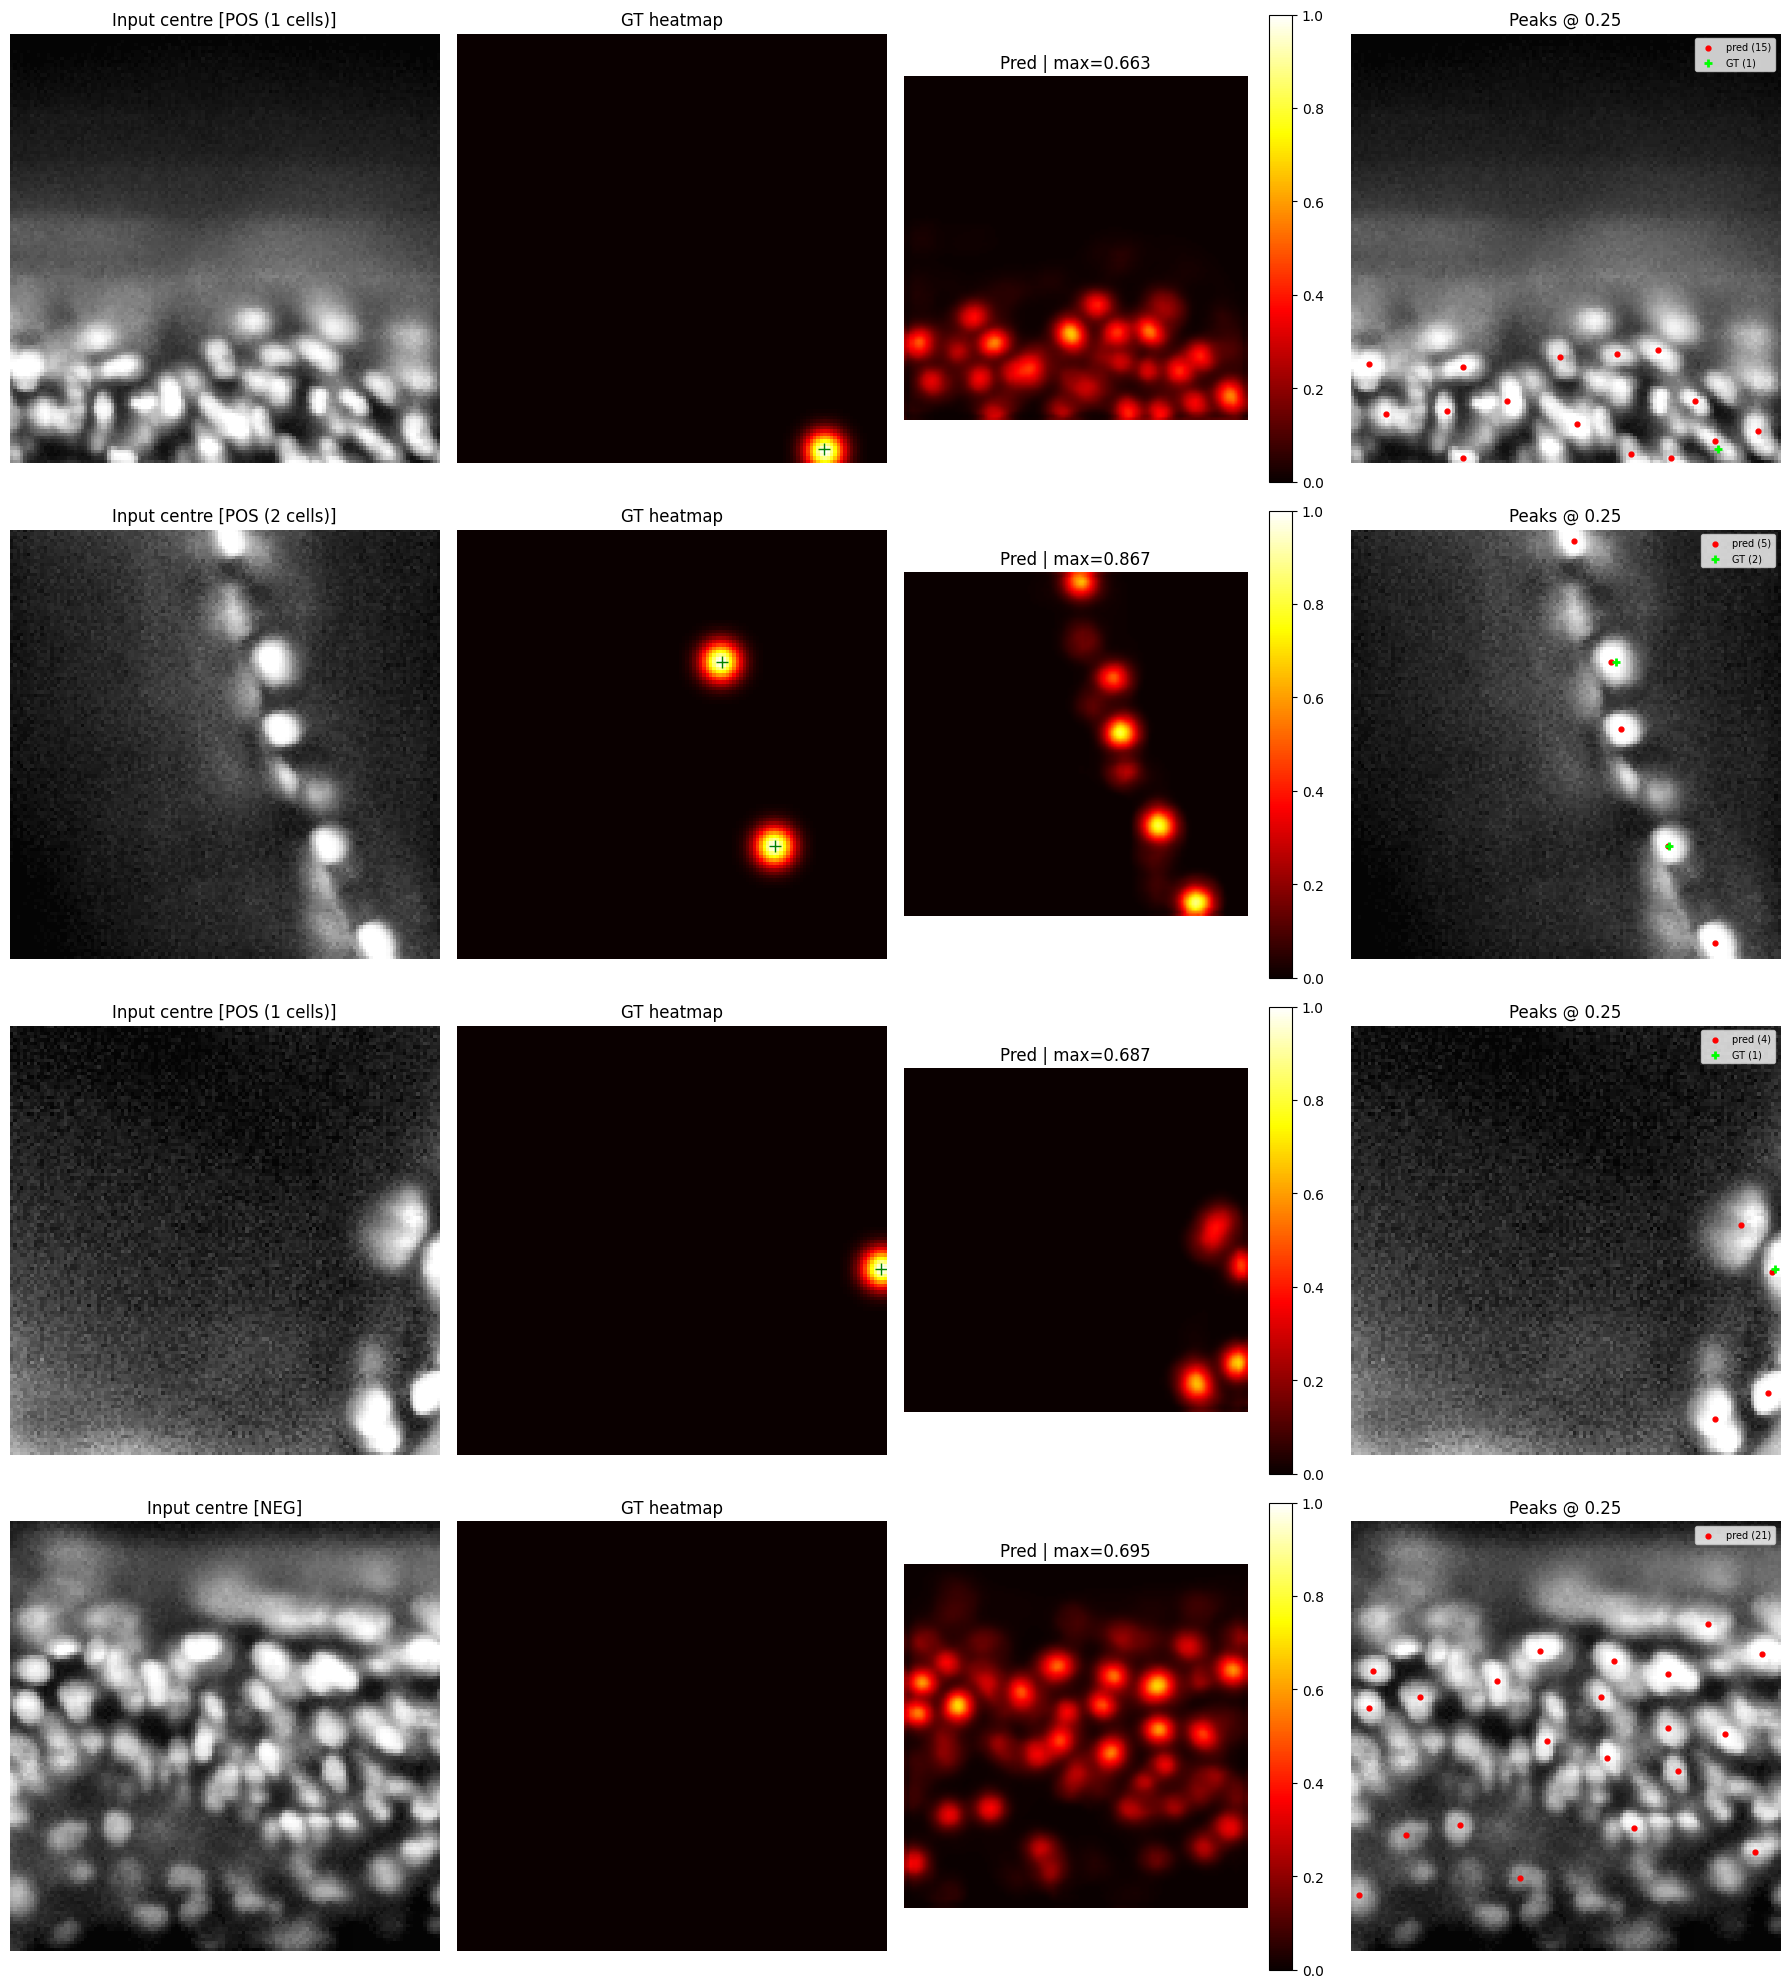

Saved: /kaggle/working/smp_val_predictions.png


In [10]:
import matplotlib.pyplot as plt

core = model.module if isinstance(model, nn.DataParallel) else model
if best_state:
    core.load_state_dict(best_state)

def visualize(model, val_cache, n=4, thresh=None):
    if thresh is None:
        thresh = best_thresh_final
    model.eval()

    pos_idx = [i for i,(s,p) in enumerate(val_cache) if len(p) > 0]
    neg_idx = [i for i,(s,p) in enumerate(val_cache) if len(p) == 0]
    sample_idx = []
    for arr, n_want in [(pos_idx, 3), (neg_idx, 1)]:
        if arr:
            sample_idx += [arr[i] for i in
                           np.linspace(0, len(arr)-1, min(n_want, len(arr)), dtype=int)]
    sample_idx = sample_idx[:n]

    fig, axes = plt.subplots(len(sample_idx), 4, figsize=(18, 5*len(sample_idx)))
    if len(sample_idx) == 1:
        axes = axes[None]

    with torch.no_grad():
        for row, idx in enumerate(sample_idx):
            ctx, pts = val_cache[idx]
            mid = ctx[IN_CHANNELS // 2]
            kind = f'NEG' if len(pts) == 0 else f'POS ({len(pts)} cells)'

            xt  = torch.from_numpy(ctx[None]).to(DEVICE)
            hm  = torch.sigmoid(model(xt))[0,0].detach().cpu().numpy()
            tgt = stamp_heatmap_2d(mid.shape, pts)

            axes[row,0].imshow(mid, cmap='gray', vmin=0, vmax=1)
            axes[row,0].set_title(f'Input centre [{kind}]')

            axes[row,1].imshow(tgt, cmap='hot', vmin=0, vmax=1)
            for cy, cx in pts:
                axes[row,1].plot(cx, cy, 'g+', ms=8)
            axes[row,1].set_title('GT heatmap')

            im = axes[row,2].imshow(hm, cmap='hot', vmin=0, vmax=1)
            axes[row,2].set_title(f'Pred | max={hm.max():.3f}')
            plt.colorbar(im, ax=axes[row,2])

            pk = peak_local_max(hm, min_distance=MIN_PEAK_DISTANCE,
                                threshold_abs=thresh, exclude_border=False)
            axes[row,3].imshow(mid, cmap='gray', vmin=0, vmax=1)
            if len(pk):
                axes[row,3].scatter(pk[:,1], pk[:,0], c='red', s=12,
                                    label=f'pred ({len(pk)})')
            if len(pts):
                axes[row,3].scatter(pts[:,1], pts[:,0], c='lime', s=30,
                                    marker='+', linewidths=2,
                                    label=f'GT ({len(pts)})')
            axes[row,3].set_title(f'Peaks @ {thresh:.2f}')
            axes[row,3].legend(fontsize=7)
            for ax in axes[row]:
                ax.axis('off')

    plt.tight_layout()
    out_path = OUT_DIR / 'smp_val_predictions.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_path}')
    model.train()

visualize(model, val_cache, n=4, thresh=0.25)